# Отчёт по проекту: анализ признаков дропперских кошельков в блокчейне

---

## 1. Введение

**Дропперский кошелёк** — временный адрес, через который проходят средства в мошеннических схемах. Обычно такой кошелёк живёт недолго, быстро переводит деньги дальше и часто получает переводы от многих разных адресов.

**Цель проекта:** найти поведенческие признаки дропперов, проверить гипотезы статистически и обучить простые модели классификации.

**Задачи:**
1. Собрать и подготовить выборку из Kaggle (`fraud` / `legitimate`).
2. Рассчитать производные признаки и очистить данные.
3. Проверить гипотезы H1–H4.
4. Обучить LogReg и KNN, оценить качество на отложенной тест-выборке.

**Источник данных:** [Kaggle Ethereum Fraud Detection](https://www.kaggle.com/datasets/vagifa/ethereum-fraud-detection) — готовые агрегаты по адресам (срок жизни, число транзакций, отправители и т.д.).

**Исследовательские гипотезы**:

| ID | Формулировка | Признак |
|----|--------------|---------|
| H1 | Срок жизни fraud-кошельков **короче**, чем у legitimate | `wallet_lifetime_days` |
| H2 | Скорость исходящих транзакций у fraud **выше** | `outbound_velocity` |
| H3 | Отношение входящих к исходящим у fraud **выше** | `in_out_tx_ratio` |
| H4 | При ≥100 отправителей доля fraud **выше** | `has_many_senders` |

---

## Этап 1. Сбор данных

Формируем реестр кошельков из Kaggle и сохраняем метаданные сбора.

| Шаг | Что делаем | Результат |
|-----|------------|-----------|
| 1.1 | Настройка окружения | каталоги `data/raw`, `data/processed` |
| 1.2 | Источники и метки | описание в тексте |
| 1.3 | Реестр адресов | `wallet_registry.csv` |
| 1.4 | Метаданные сбора | `collection_metadata.json` |
| 1.5 | Итоги этапа | краткие выводы |


### 1.1 Настройка окружения

Подключаем библиотеки и задаём пути к каталогам с сырыми и обработанными данными.


In [200]:
import json
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Проект: {PROJECT_ROOT}")
print(f"Данные: {RAW_DIR}")


Проект: C:\Users\pauqs\PycharmProjects\data_analysis
Данные: C:\Users\pauqs\PycharmProjects\data_analysis\data\raw


### 1.2 Источники данных

**Источник** — датасет Kaggle Ethereum Fraud Detection. В нём уже посчитаны агрегаты по каждому адресу.

| Метка | Значение в Kaggle | Смысл |
|-------|-------------------|-------|
| `fraud` | `FLAG = 1` | Подозрительный / мошеннический кошелёк |
| `legitimate` | `FLAG = 0` | Обычный кошелёк |

Все этапы (гипотезы, модели) выполняются **только на этих данных**.


### 1.3 Загрузка и объединение адресов

1. Загружаем Kaggle-датасет (при первом запуске скачивается зеркало с GitHub).
2. Берём стратифицированную выборку `KAGGLE_SAMPLE = 1000` (500 fraud + 500 legitimate).
3. Сохраняем реестр `wallet_registry.csv`.


In [201]:
from src.label_sources import (
    build_wallet_registry,
    fetch_kaggle_fraud_dataset,
    save_registry,
)

KAGGLE_SAMPLE = 1000

kaggle_df = fetch_kaggle_fraud_dataset(RAW_DIR / "kaggle_transaction_dataset.csv")
print(f"Kaggle: {len(kaggle_df)} адресов (fraud={(kaggle_df['label']=='fraud').sum()}, legit={(kaggle_df['label']=='legitimate').sum()})")


Kaggle: 9841 адресов (fraud=2179, legit=7662)


In [202]:
registry = build_wallet_registry(
    RAW_DIR, sample_kaggle=KAGGLE_SAMPLE, include_controls=False
)
save_registry(registry, PROCESSED_DIR / "wallet_registry.csv")

print(f"Итого в реестре: {len(registry)} кошельков")
display(registry["label"].value_counts().to_frame("count"))


Итого в реестре: 1000 кошельков


,count
label,
legitimate,500
fraud,500


In [203]:
registry.head(10)


,address,label,category,entity,source,chain,raw_features,wallet_id
0,0x85fd5810b0f3924fc47546b6123d48187e7ec47c,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 5061, 'Index': 2129, 'Avg min b...",1
1,0x408829f5361f5fbca529a14bea22f16663713af9,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 2471, 'Index': 2472, 'Avg min b...",2
2,0x13a4cb8bc78679d35956c8ddc50e110df7520077,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 800, 'Index': 801, 'Avg min bet...",3
3,0x904f3512563e5c02b34b2c140a4be16c371628c4,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 5428, 'Index': 2496, 'Avg min b...",4
4,0x23acbc073abc5011d2bcef6ffb4ccc8a695686b2,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 1406, 'Index': 1407, 'Avg min b...",5
5,0xa9405926aa26d16e5bfe3b24ca905d8b4d0a6cd4,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 6339, 'Index': 3407, 'Avg min b...",6
6,0x3bcca5956ef09efebb5652acf3ad77ba2be2b04e,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 2291, 'Index': 2292, 'Avg min b...",7
7,0x9d8be5a612604715ab30a9914c20527b0410198a,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 5894, 'Index': 2962, 'Avg min b...",8
8,0x1858de90f17fb45e799521200fb28eb60e11e0e2,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 982, 'Index': 983, 'Avg min bet...",9
9,0xbc2cbee1287f175c8ba0fe9c3cdc59268278b8e7,legitimate,kaggle_legit,None,kaggle_mirror,ETH,"{'Unnamed: 0': 7026, 'Index': 4094, 'Avg min b...",10


**Результаты.** Реестр **1000** размеченных Kaggle-адресов (500 fraud + 500 legitimate).

| Поле | Описание |
|------|----------|
| `address` | ETH (`0x…`) |
| `label` | `fraud` / `legitimate` |
| `flag` | 1 / 0 — целевая переменная для модели |
| `source` | `kaggle_mirror` |


### 1.4 Сохранение метаданных сбора

Фиксируем параметры этапа 1 в `collection_metadata.json`.


In [204]:
metadata = {
    "total_wallets": len(registry),
    "by_label": registry["label"].value_counts().to_dict(),
    "by_source": registry["source"].value_counts().to_dict(),
    "kaggle_sample": KAGGLE_SAMPLE,
    "sources": ["kaggle_mirror"],
}

meta_path = PROCESSED_DIR / "collection_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Метаданные: {meta_path}")


Метаданные: C:\Users\pauqs\PycharmProjects\data_analysis\data\processed\collection_metadata.json


### 1.5 Итоги этапа 1

**Сделано:**
- реестр **1000** Kaggle-адресов (стратифицированная выборка);
- файл `wallet_registry.csv` и `collection_metadata.json`.

**Дальше:** этап 2 — матрица признаков `wallet_features.csv`.


---

## Этап 2. Очистка и предобработка данных

**Импутация:** пропуски заполняем медианой внутри класса (`fraud` / `legitimate`).


### 2.1 Построение матрицы признаков

`build_feature_matrix` читает агрегаты из Kaggle CSV и добавляет производные признаки (`wallet_lifetime_days`, `outbound_velocity` и др.).


In [205]:
import importlib
import src.preprocessing as preprocessing

importlib.reload(preprocessing)
print("preprocessing перезагружен:", preprocessing.__file__)


preprocessing перезагружен: C:\Users\pauqs\PycharmProjects\data_analysis\src\preprocessing.py


In [206]:
from src.preprocessing import (
    build_feature_matrix,
    save_feature_matrix,
    save_quality_report,
)

KAGGLE_PATH = RAW_DIR / "kaggle_transaction_dataset.csv"

features, quality_report = build_feature_matrix(registry, KAGGLE_PATH, tx_dir=None)

print(f"Матрица: {features.shape[0]} строк, {features.shape[1]} колонок")
print(f"Размечено (flag 0/1): {features['flag'].isin([0, 1]).sum()}")
display(features.head(3))

save_feature_matrix(features, PROCESSED_DIR / "wallet_features.csv")
save_quality_report(quality_report, PROCESSED_DIR / "feature_quality_report.json")
print(f"Сохранено: {PROCESSED_DIR / 'wallet_features.csv'}")


Матрица: 1002 строк, 42 колонок
Размечено (flag 0/1): 1002


,address,label,category,entity,source,chain,raw_features,wallet_id,flag,lifetime_mins,...,wallet_lifetime_days_was_winsorized,tx_per_day_was_winsorized,outbound_velocity_was_winsorized,unique_senders_was_winsorized,in_out_tx_ratio_was_winsorized,label_code,is_high_risk,category_code,source_code,chain_code
0,0x85fd5810b0f3924fc47546b6123d48187e7ec47c,legitimate,kaggle_legit,unknown,kaggle_mirror,ETH,"{'Unnamed: 0': 5061, 'Index': 2129, 'Avg min b...",1,0,100993.85,...,0,0,0,0,0,0,0,1,0,0
1,0x408829f5361f5fbca529a14bea22f16663713af9,legitimate,kaggle_legit,unknown,kaggle_mirror,ETH,"{'Unnamed: 0': 2471, 'Index': 2472, 'Avg min b...",2,0,62.87,...,0,0,1,0,0,0,0,1,0,0
2,0x13a4cb8bc78679d35956c8ddc50e110df7520077,legitimate,kaggle_legit,unknown,kaggle_mirror,ETH,"{'Unnamed: 0': 800, 'Index': 801, 'Avg min bet...",3,0,3.85,...,0,0,0,0,0,0,0,1,0,0


Сохранено: C:\Users\pauqs\PycharmProjects\data_analysis\data\processed\wallet_features.csv


**Результат (2.1).** Матрица **1000** размеченных Kaggle-кошельков. Все признаки — из CSV датасета.


### 2.2 Качество данных: пропуски и импутация

В Kaggle-выборке пропуски встречаются редко; при merge они заполняются по стратегии ниже.

**Стратегия (без NaN в итоговой матрице):**

1. **Медиана по `label`** — отдельно для fraud и legitimate.
2. **Глобальная медиана** — если в группе нет наблюдений.

Медиана устойчивее среднего к выбросам. Все тесты и модели — только на Kaggle (`flag` = 0 или 1).


In [207]:
imputation_df = pd.DataFrame(quality_report["imputation"])
if not imputation_df.empty:
    display(imputation_df.head(12))
else:
    print("Пропусков в числовых колонках не обнаружено")

print(f"\nNaN в матрице: {quality_report.get('nan_total', int(features.isna().sum().sum()))}")


Пропусков в числовых колонках не обнаружено

NaN в матрице: 0


**Итог (2.2).** Пропуски заполнены медианой по классу. В матрице **0 NaN**. Все тесты — на Kaggle (`flag` = 0 или 1).


### 2.3 Производные признаки и выбросы

Рассчитываем метрики для последующей проверки гипотез на **этапе 3**:

| Признак | Смысл | Гипотеза |
|---------|-------|----------|
| `wallet_lifetime_days` | срок жизни кошелька | H1 |
| `outbound_velocity` | исходящие транзакции / день | H2 |
| `in_out_tx_ratio` | входящие / исходящие | H3 |
| `has_many_senders` | unique_senders ≥ 100 | H4 |
| `tx_per_day` | оборачиваемость | описательно |

Выбросы — IQR-флаги и винзоризация (уже в `build_feature_matrix`).


In [208]:
key_metrics = [
    "wallet_lifetime_days",
    "tx_per_day",
    "outbound_velocity",
    "unique_senders",
    "in_out_tx_ratio",
]

summary = (
    features.groupby("label")[key_metrics]
    .agg(["median", "mean", "count"])
    .round(2)
)
display(summary)

anomaly_cols = [c for c in features.columns if c.endswith("_is_anomaly")]
if anomaly_cols:
    print("\nДоля аномалий по меткам (IQR):")
    display(
        features.groupby("label")[anomaly_cols]
        .mean()
        .round(3)
    )

winsor_cols = [c for c in features.columns if c.endswith("_was_winsorized")]
if winsor_cols:
    print("\nСколько значений винзоризовано:")
    display(
        features[winsor_cols]
        .sum()
        .to_frame("rows_adjusted")
        .sort_values("rows_adjusted", ascending=False)
    )

winsor_df = pd.DataFrame(quality_report.get("winsorization", []))
if not winsor_df.empty:
    print("\nГраницы винзоризации:")
    display(winsor_df)


wallet_lifetime_days               tx_per_day              \
                         median    mean count     median  mean count   
label                                                                  
fraud                      5.28   33.54   500       0.44  1.39   500   
legitimate                70.29  128.64   502       0.93  1.97   502   

           outbound_velocity             unique_senders              \
                      median  mean count         median  mean count   
label                                                                 
fraud                   0.04  0.32   500            3.0  4.98   500   
legitimate              0.28  0.90   502            2.0  3.72   502   

           in_out_tx_ratio              
                    median  mean count  
label                                   
fraud                  2.0  2.10   500  
legitimate             1.0  0.98   502


Доля аномалий по меткам (IQR):


,wallet_lifetime_days_is_anomaly,tx_per_day_is_anomaly,outbound_velocity_is_anomaly,unique_senders_is_anomaly,in_out_tx_ratio_is_anomaly
label,,,,,
fraud,0.004,0.056,0.032,0.194,0.222
legitimate,0.195,0.034,0.193,0.076,0.046



Сколько значений винзоризовано:


,rows_adjusted
unique_senders_was_winsorized,135
in_out_tx_ratio_was_winsorized,134
outbound_velocity_was_winsorized,113
wallet_lifetime_days_was_winsorized,100
tx_per_day_was_winsorized,45



Границы винзоризации:


,column,lower,upper,rows_adjusted
0,wallet_lifetime_days,-206.808018,344.830989,100
1,tx_per_day,-4.239310,7.343586,45
2,outbound_velocity,-1.500000,2.500000,113
3,unique_senders,-6.500000,13.500000,135
4,in_out_tx_ratio,-0.500000,3.500000,134


**Наблюдения перед формальными тестами (этап 3):**
- у `fraud` медианный срок жизни заметно короче (ожидание H1);
- у `legitimate` выше `outbound_velocity` — на первый взгляд против H2.


### 2.4 Итоги этапа 2

**Сделано:**
- `wallet_features.csv` — 1000 Kaggle-адресов;
- импутация, обработка выбросов, производные признаки.

**Дальше:** этап 3 — проверка гипотез H1–H4.


---

## Этап 3. Анализ данных и проверка гипотез

Проверяем, отличаются ли fraud- и legitimate-кошельки по ключевым признакам. Используем только Kaggle-выборку (`flag` = 0 или 1).

**Mann–Whitney U** — непараметрический тест для сравнения двух групп. Подходит для скошенных распределений (у нас много выбросов по сроку жизни и числу транзакций).


### 3.1 Подготовка выборки

Берём только строки с известной меткой (`flag` {0, 1}). Для сравнения групп используем **медиану** — она устойчивее среднего к выбросам.


In [209]:
from scipy import stats

kaggle_df = features[features["flag"].isin([0, 1])].copy()
fraud = kaggle_df[kaggle_df["flag"] == 1]
legit = kaggle_df[kaggle_df["flag"] == 0]

print(f"Выборка для тестов: {len(kaggle_df)} (fraud={len(fraud)}, legitimate={len(legit)})")


Выборка для тестов: 1002 (fraud=500, legitimate=502)


### 3.2 Проверка гипотез H1–H3 (Mann–Whitney U)

| H | H₀ | Альтернатива | Признак |
|---|----|--------------|---------|
| H1 | распределения равны | fraud < legitimate | `wallet_lifetime_days` |
| H2 | распределения равны | fraud > legitimate | `outbound_velocity` |
| H3 | распределения равны | fraud > legitimate | `in_out_tx_ratio` |

Уровень значимости α = 0.05.


In [210]:
METRICS = {
    "H1": ("wallet_lifetime_days", "less"),
    "H2": ("outbound_velocity", "greater"),
    "H3": ("in_out_tx_ratio", "greater"),
}

rows = []
for hid, (col, alt) in METRICS.items():
    x = fraud[col].dropna()
    y = legit[col].dropna()
    stat, p = stats.mannwhitneyu(x, y, alternative=alt)
    rows.append({
        "hypothesis": hid,
        "metric": col,
        "fraud_median": x.median(),
        "legit_median": y.median(),
        "U": stat,
        "p_value": p,
        "reject_H0": p < 0.05,
    })

mw_results = pd.DataFrame(rows)
display(mw_results)


,hypothesis,metric,fraud_median,legit_median,U,p_value,reject_H0
0,H1,wallet_lifetime_days,5.278542,70.285653,81305.0,2.114877e-22,True
1,H2,outbound_velocity,0.044034,0.281984,78965.0,1.000000e+00,False
2,H3,in_out_tx_ratio,2.000000,1.000000,209091.0,3.965181e-77,True


### 3.3 Проверка гипотезы H4 (критерий Фишера)

**H4:** среди кошельков с `unique_senders` ≥ 100 доля fraud **выше**, чем у кошельков с меньшим числом отправителей.

Строим таблицу `has_many_senders` × `flag` и применяем **точный критерий Фишера** с односторонней альтернативой `greater` (доля fraud в группе «много отправителей» выше).


In [211]:
ct = pd.crosstab(kaggle_df["has_many_senders"], kaggle_df["flag"])
display(ct)

n_fraud_high = int(ct.loc[1, 1]) if 1 in ct.index and 1 in ct.columns else 0
n_high = int(ct.loc[1].sum()) if 1 in ct.index else 0
n_fraud_low = int(ct.loc[0, 1]) if 0 in ct.index and 1 in ct.columns else 0
n_low = int(ct.loc[0].sum()) if 0 in ct.index else 0

rate_high = n_fraud_high / n_high if n_high else float("nan")
rate_low = n_fraud_low / n_low if n_low else float("nan")
h4_direction_ok = rate_high > rate_low

odds_ratio, p_h4 = stats.fisher_exact(ct.values, alternative="greater")
h4_confirmed = p_h4 < 0.05 and h4_direction_ok

print(f"Доля fraud (>=100 отправителей): {rate_high:.1%}  (n={n_high})")
print(f"Доля fraud (<100 отправителей):  {rate_low:.1%}  (n={n_low})")
print(f"odds ratio={odds_ratio:.2f}, p (one-sided)={p_h4:.4g}")
print(f"Направление совпадает с H4: {h4_direction_ok}")
print(f"H4 подтверждена (alpha=0.05): {h4_confirmed}")


flag,0,1
has_many_senders,,
0,499,490
1,3,10


Доля fraud (>=100 отправителей): 76.9%  (n=13)
Доля fraud (<100 отправителей):  49.5%  (n=989)
odds ratio=3.39, p (one-sided)=0.04441
Направление совпадает с H4: True
H4 подтверждена (alpha=0.05): True


### 3.4 Сводка и интерпретация

Объединяем результаты всех тестов. Гипотеза **подтверждается**, если p < 0.05 и направление эффекта совпадает с формулировкой.


In [212]:
h4_row = pd.DataFrame([{
    "hypothesis": "H4",
    "metric": "has_many_senders x flag (Fisher)",
    "fraud_median": rate_high,
    "legit_median": rate_low,
    "U": odds_ratio,
    "p_value": p_h4,
    "reject_H0": h4_confirmed,
}])

summary = pd.concat([mw_results, h4_row], ignore_index=True)
display(summary)

confirmed = summary.loc[summary["reject_H0"], "hypothesis"].tolist()
print("Подтверждены:", ", ".join(confirmed) if confirmed else "нет")
print("Не подтверждены:", ", ".join(set(summary["hypothesis"]) - set(confirmed)))


,hypothesis,metric,fraud_median,legit_median,U,p_value,reject_H0
0,H1,wallet_lifetime_days,5.278542,70.285653,81305.000000,2.114877e-22,True
1,H2,outbound_velocity,0.044034,0.281984,78965.000000,1.000000e+00,False
2,H3,in_out_tx_ratio,2.000000,1.000000,209091.000000,3.965181e-77,True
3,H4,has_many_senders x flag (Fisher),0.769231,0.495450,3.394558,4.441255e-02,True


Подтверждены: H1, H3, H4
Не подтверждены: H2


#### Интерпретация результатов

**H1 (срок жизни) — подтверждена.** Медиана у fraud заметно ниже, чем у legitimate. Короткий срок жизни — сильный признак дроппера.

**H2 (скорость исходящих) — не подтверждена.** У fraud медиана `outbound_velocity` ниже, а не выше (односторонний Mann–Whitney с `greater` даёт p ≈ 1). Причина связана с H1: короткоживущий кошелёк не успевает набрать высокую дневную скорость, тогда как обычные кошельки копят историю годами.

**H3 (вход/выход) — подтверждена.** Медиана `in_out_tx_ratio` у fraud выше — типичная картина сбора средств с многих адресов.

**H4 (много отправителей) — подтверждена.** Доля fraud среди кошельков с ≥100 отправителей выше, чем среди остальных; односторонний Fisher exact даёт p < 0.05. Подгруппа мала (десятки адресов), поэтому вывод осторожный: эффект есть, но оценён на небольшой выборке.


### 3.5 Итоги этапа 3

На Kaggle-выборке (~1000 адресов) подтверждены **H1**, **H3** и **H4**, отклонена **H2**.

**Следующий шаг:** корреляционный анализ и классификация (LogReg, KNN) на `wallet_features.csv`.


---

## Этап 4. Корреляционный анализ и классификация

| Шаг | Метод | Цель |
|-----|-------|------|
| 4.1 | Корреляция Пирсона и Спирмена | Связь признаков с меткой `flag` |
| 4.2 | Логистическая регрессия | Первая модель |
| 4.3 | KNN | Вторая модель, подбор k через CV |
| 4.4 | Сравнение моделей | Метрики и ROC на Kaggle test |
| 4.5 | Итоги | Выводы |

**Разбиение данных:** 80% train (обучение и подбор k), 20% test (финальная оценка).


### 4.1 Корреляционный анализ признаков

Перед обучением смотрим, насколько каждый признак связан с меткой fraud (0/1).

| | Пирсон (r) | Спирмен (ρ) |
|---|---|---|
| Что измеряет | линейную связь | любую монотонную связь |
| Чувствительность к выбросам | высокая | низкая |

Признаки кошельков сильно скошены (редкие «очень активные» адреса). **Ориентируемся на Спирмена**; Пирсон — для сравнения.


In [213]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

assert "features" in dir(), "Переменная features не найдена — сначала выполните этап 2 (п. 2.1)"

kaggle_df = features[features["flag"].isin([0, 1])].copy()

print(f"Выборка: {len(kaggle_df)} кошельков (fraud={kaggle_df['flag'].eq(1).sum()}, legitimate={kaggle_df['flag'].eq(0).sum()})")



Выборка: 1002 кошельков (fraud=500, legitimate=502)


#### Корреляция признаков с меткой `flag`

В модель идут **4 признака** из этапа 3:

| Признак | Гипотеза | Зачем в модели |
|---------|----------|----------------|
| `wallet_lifetime_days` | H1 ✓ | подтверждённый маркер |
| `outbound_velocity` | H2 ✗ | оставлен: коррелирует с fraud, несмотря на отказ H2 |
| `in_out_tx_ratio` | H3 ✓ | подтверждённый маркер |
| `unique_senders` | H4 ✓ | число отправителей (непрерывный аналог H4) |


In [214]:
FEATURE_COLS = [
    "wallet_lifetime_days",
    "outbound_velocity",    
    "in_out_tx_ratio",     
    "unique_senders" 
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in kaggle_df.columns]
target = kaggle_df["flag"]

rows = []
for col in FEATURE_COLS:
    x = kaggle_df[col].dropna()
    idx = x.index
    r_p, p_p = stats.pearsonr(x, target.loc[idx])
    r_s, p_s = stats.spearmanr(x, target.loc[idx])
    rows.append({
        "Признак": col,
        "Пирсон r": round(r_p, 3),
        "p (Пирсон)": round(p_p, 4),
        "Спирмен ρ": round(r_s, 3),
        "p (Спирмен)": round(p_s, 4),
        "Δ |r−ρ|": round(abs(abs(r_p) - abs(r_s)), 3),
    })

corr_df = pd.DataFrame(rows).sort_values("Спирмен ρ", key=abs, ascending=False)
display(corr_df)


,Признак,Пирсон r,p (Пирсон),Спирмен ρ,p (Спирмен),Δ |r−ρ|
2,in_out_tx_ratio,0.558,0.0,0.586,0.0000,0.028
1,outbound_velocity,-0.331,0.0,-0.325,0.0000,0.007
0,wallet_lifetime_days,-0.404,0.0,-0.305,0.0000,0.099
3,unique_senders,0.139,0.0,0.004,0.9003,0.135


> **Как читать таблицу:** чем больше |ρ|, тем сильнее признак связан с fraud. Большая разница |r| и |ρ| — признак с выбросами; для него надёжнее Спирмен.


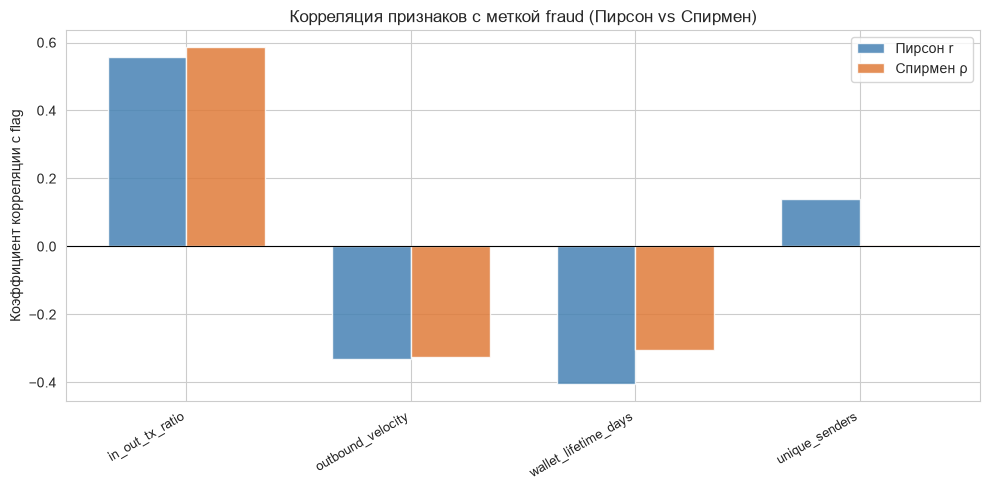

In [215]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(corr_df))
bar_w = 0.35

bars_p = ax.bar(x_pos - bar_w/2, corr_df["Пирсон r"],  width=bar_w, label="Пирсон r",  color="steelblue",  alpha=0.85)
bars_s = ax.bar(x_pos + bar_w/2, corr_df["Спирмен ρ"], width=bar_w, label="Спирмен ρ", color="#e07b39", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(corr_df["Признак"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Коэффициент корреляции с flag")
ax.set_title("Корреляция признаков с меткой fraud (Пирсон vs Спирмен)")
ax.legend()
plt.tight_layout()
plt.show()


#### Корреляционная матрица признаков

Смотрим на взаимосвязи между самими признаками.  
Сильная корреляция между двумя признаками — сигнал о мультиколлинеарности: они несут похожую информацию.


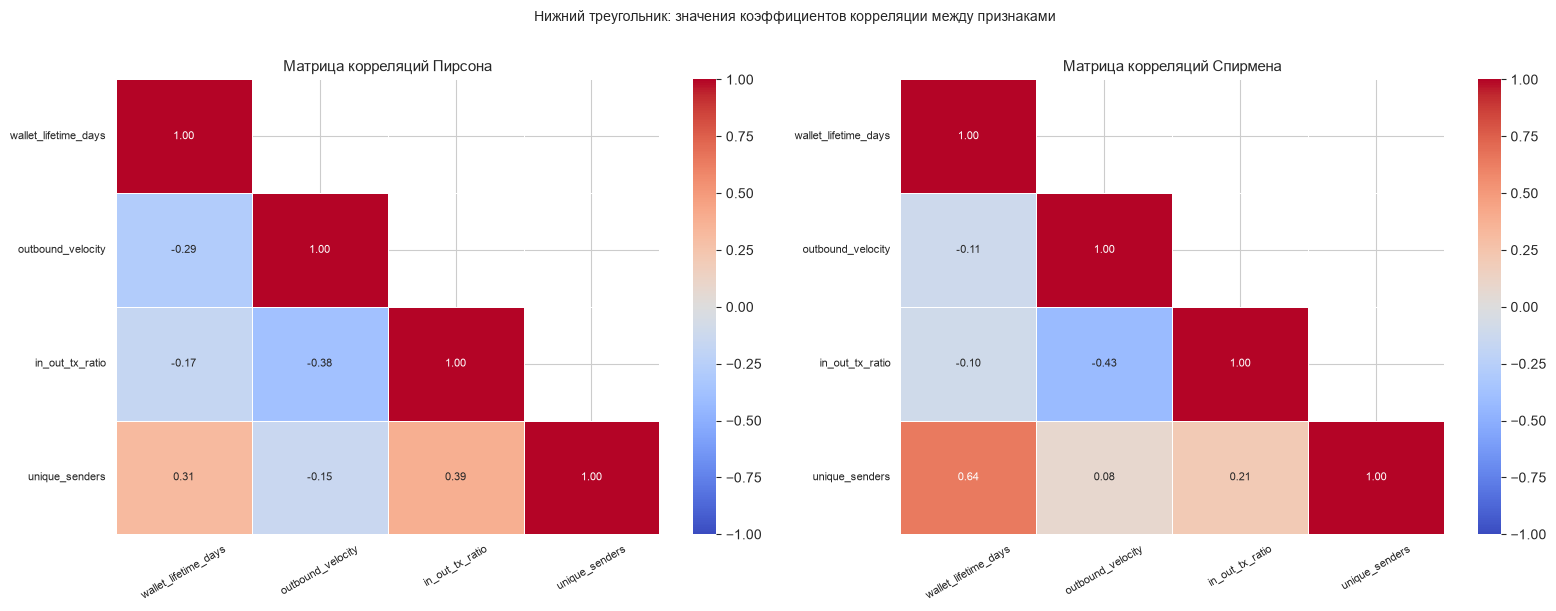

In [216]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method, title in zip(axes,
                               ["pearson",  "spearman"],
                               ["Матрица корреляций Пирсона", "Матрица корреляций Спирмена"]):
    matrix = kaggle_df[FEATURE_COLS].corr(method=method)
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    sns.heatmap(
        matrix, ax=ax, mask=mask,
        annot=True, fmt=".2f", cmap="coolwarm",
        vmin=-1, vmax=1, linewidths=0.5,
        annot_kws={"size": 8},
    )
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Нижний треугольник: значения коэффициентов корреляции между признаками", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


**В наших данных:** максимум ρ = 0.64 (между wallet_lifetime_days и unique_senders). Порог не достигнут, все 4 признака оставлены в модели.


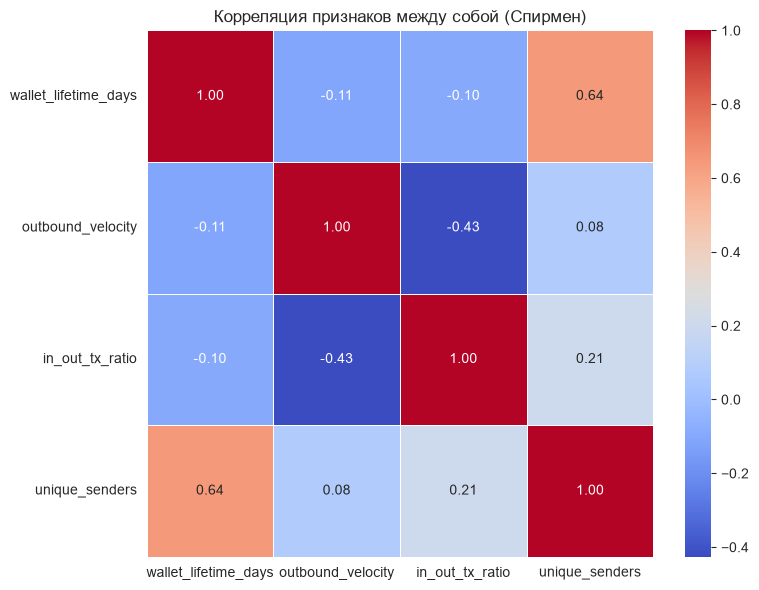

In [217]:
plt.figure(figsize=(8, 6))
corr_matrix = kaggle_df[FEATURE_COLS].corr(method='spearman')

sns.heatmap(
    corr_matrix, 
    annot=True,      
    cmap='coolwarm', 
    fmt=".2f",       
    linewidths=0.5
)

plt.title("Корреляция признаков между собой (Спирмен)")
plt.tight_layout()
plt.show()

### 4.2 Логистическая регрессия

Модель оценивает вероятность fraud по линейной комбинации признаков:

$$P(\text{fraud} \mid x) = \frac{1}{1 + e^{-z}}, \quad z = w_0 + w_1 x_1 + \ldots + w_n x_n$$

**Шаги:**
1. Делим Kaggle-выборку: 80% train, 20% test (`stratify` — сохраняем баланс классов).
2. Масштабируем признаки (`StandardScaler`) — только на train, затем применяем к test.

Для поиска мошенников важен **recall по fraud**: лучше ложная тревога, чем пропущенный дроппер.


In [218]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
)

X = kaggle_df[FEATURE_COLS].values
y = kaggle_df["flag"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Баланс классов (train): fraud={y_train.sum()}, legit={(y_train==0).sum()}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


Train: 801  |  Test: 201
Баланс классов (train): fraud=400, legit=401


In [219]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]

print("Логистическая регрессия (test)")
print(classification_report(y_test, y_pred_lr, target_names=["legitimate", "fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")


Логистическая регрессия (test)
              precision    recall  f1-score   support

  legitimate       0.82      0.85      0.83       101
       fraud       0.84      0.81      0.83       100

    accuracy                           0.83       201
   macro avg       0.83      0.83      0.83       201
weighted avg       0.83      0.83      0.83       201

ROC-AUC: 0.902


#### Коэффициенты модели

Коэффициенты показывают вклад каждого признака. Сравнивать их по величине корректно — признаки масштабированы.

- **Положительный коэффициент** → признак увеличивает вероятность fraud.  
- **Отрицательный** → уменьшает.


,Признак,Коэффициент
0,wallet_lifetime_days,-2.1772
2,in_out_tx_ratio,1.1770
1,outbound_velocity,-1.0120
3,unique_senders,0.9126


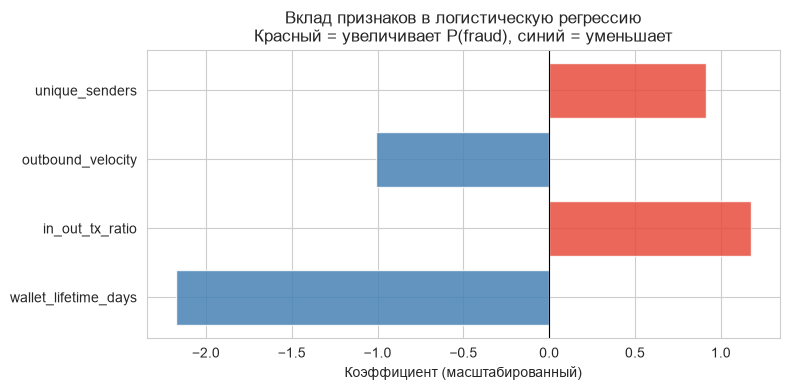

In [220]:
coef_df = (
    pd.DataFrame({"Признак": FEATURE_COLS, "Коэффициент": lr.coef_[0]})
    .sort_values("Коэффициент", key=abs, ascending=False)
)
display(coef_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c" if c > 0 else "steelblue" for c in coef_df["Коэффициент"]]
ax.barh(coef_df["Признак"], coef_df["Коэффициент"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Коэффициент (масштабированный)")
ax.set_title("Вклад признаков в логистическую регрессию\nКрасный = увеличивает P(fraud), синий = уменьшает")
plt.tight_layout()
plt.show()


Для задачи выявления дропперов особенно важен **Recall по fraud**: пропустить мошенника хуже, чем ложно заподозрить легитимного.


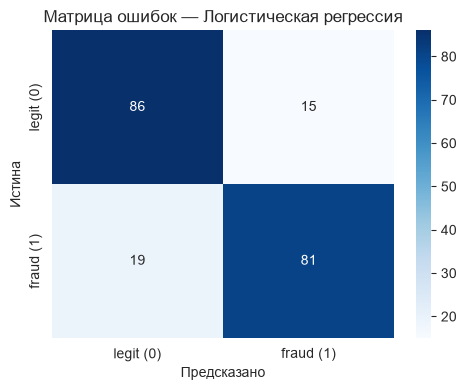

In [221]:
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["legit (0)", "fraud (1)"],
    yticklabels=["legit (0)", "fraud (1)"],
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Истина")
ax.set_title("Матрица ошибок — Логистическая регрессия")
plt.tight_layout()
plt.show()


### 4.3 Метод k ближайших соседей (KNN)

KNN классифицирует объект по меткам **k** ближайших соседей в пространстве признаков.

**Подбор k:** кросс-валидация на **train** (5 фолдов), метрика F1. Тестовая выборка в подборе **не участвует** — иначе метрики на test будут завышены.

Лучшее k = 7  (средний F1 на CV = 0.895)


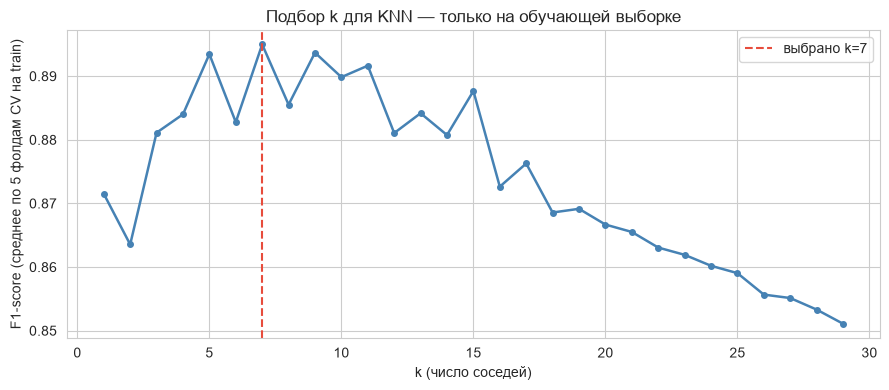

In [222]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

k_candidates = list(range(1, 30))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": k_candidates},
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train_sc, y_train)
best_k = grid.best_params_["n_neighbors"]

print(f"Лучшее k = {best_k}  (средний F1 на CV = {grid.best_score_:.3f})")

cv_results_df = pd.DataFrame(grid.cv_results_)
cv_scores = (
    cv_results_df.groupby(cv_results_df["param_n_neighbors"].astype(int))["mean_test_score"]
    .first()
    .reset_index()
    .rename(columns={"param_n_neighbors": "k", "mean_test_score": "F1 (CV, mean)"})
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cv_scores["k"], cv_scores["F1 (CV, mean)"], marker="o", markersize=4, color="steelblue", linewidth=1.8)
ax.axvline(best_k, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"выбрано k={best_k}")
ax.set_xlabel("k (число соседей)")
ax.set_ylabel("F1-score (среднее по 5 фолдам CV на train)")
ax.set_title("Подбор k для KNN — только на обучающей выборке")
ax.legend()
plt.tight_layout()
plt.show()



In [223]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)

y_pred_knn  = knn.predict(X_test_sc)
y_proba_knn = knn.predict_proba(X_test_sc)[:, 1]

print(f"KNN (k={best_k}, test)")
print(classification_report(y_test, y_pred_knn, target_names=["legitimate", "fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_knn):.3f}")


KNN (k=7, test)
              precision    recall  f1-score   support

  legitimate       0.84      0.89      0.87       101
       fraud       0.88      0.83      0.86       100

    accuracy                           0.86       201
   macro avg       0.86      0.86      0.86       201
weighted avg       0.86      0.86      0.86       201

ROC-AUC: 0.935


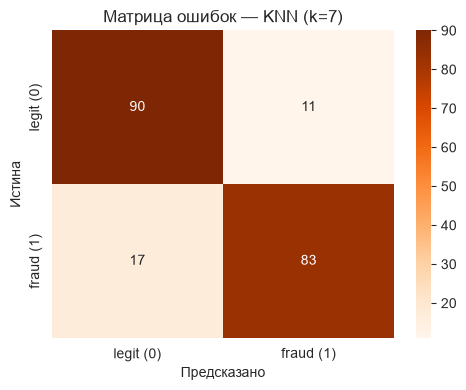

In [224]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["legit (0)", "fraud (1)"],
    yticklabels=["legit (0)", "fraud (1)"],
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Истина")
ax.set_title(f"Матрица ошибок — KNN (k={best_k})")
plt.tight_layout()
plt.show()


### 4.4 Сравнение моделей

Сводим метрики обеих моделей в одну таблицу и визуализируем ROC-кривые.

**ROC-кривая** показывает, как меняется соотношение верно предсказанных fraud (TPR) и ложных тревог (FPR) при разных порогах классификации.  
**AUC** (площадь под кривой): 0.5 — случайное угадывание, 1.0 — идеальная модель.


In [225]:
from sklearn.metrics import roc_curve

comparison = pd.DataFrame({
    "Модель": ["Логистическая регрессия", f"KNN (k={best_k})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
    ],
    "Precision (fraud)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
    ],
    "Recall (fraud)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
    ],
    "F1 (fraud)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_knn),
    ],
}).round(3)

display(comparison)


,Модель,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC
0,Логистическая регрессия,0.831,0.844,0.81,0.827,0.902
1,KNN (k=7),0.861,0.883,0.83,0.856,0.935


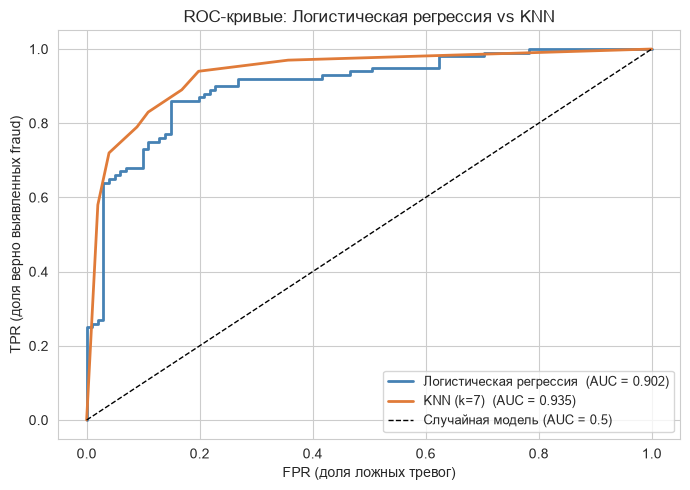

In [226]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_proba, color in [
    ("Логистическая регрессия", y_proba_lr,  "steelblue"),
    (f"KNN (k={best_k})",       y_proba_knn, "#e07b39"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Случайная модель (AUC = 0.5)")
ax.set_xlabel("FPR (доля ложных тревог)")
ax.set_ylabel("TPR (доля верно выявленных fraud)")
ax.set_title("ROC-кривые: Логистическая регрессия vs KNN")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


> **ROC-AUC:** площадь под кривой. 0.5 — случайное угадывание, 1.0 — идеальное разделение классов.


### 4.5 Итоги этапа 4

**Корреляции (4.1).** Сильнее всего с fraud связаны `wallet_lifetime_days` и `in_out_tx_ratio` (согласуется с H1 и H3). Для скошенных данных надёжнее Спирмен.

**Модели на Kaggle test (4.2–4.4).**
- LogReg и KNN дают F1 около 0.84–0.87 на отложенных 20% выборки.
- KNN: k подобран кросс-валидацией на train.
- LogReg чуть выше по ROC-AUC — лучше ранжирует вероятности fraud.

**Итог по проекту**

На датасете Kaggle подтверждены короткий срок жизни и высокое соотношение входящих/исходящих транзакций у fraud-кошельков. Простые модели (логистическая регрессия и KNN) разделяют классы с приемлемым качеством. Ограничение: выводы относятся к признакам и разметке Kaggle; перенос на другие источники не проверялся.